# Genz Function in Dakota and QMCPy

Original QMCPy demo: [`QMCPy/demos/DAKOTA_Genz/dakota_genz.ipynb`](../../../QMCPy/demos/DAKOTA_Genz/dakota_genz.ipynb)

The original Python notebook performs a broad comparison that includes Dakota point sets. This Julia translation focuses on the overlapping `QMC.jl` samplers and the same Genz benchmark families.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/DAKOTA_Genz/dakota_genz.ipynb)

In [1]:
using QMC
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## Benchmark Setup

We compare `IIDStdUniform`, `Lattice`, and `DigitalNetB2` on two standard Genz test functions. A high-accuracy digital-net solve serves as the reference value.


In [2]:
d = 4
a = ones(d)
u = 0.5 .* ones(d)
kinds = [:oscillatory, :corner_peak]

function reference_solution(kind)
    dd = DigitalNetB2(d; seed=17, graycode=false)
    f = Genz(Uniform(dd); kind=kind, a=a, u=u)
    return integrate(CubQMCNetG(f; abs_tol=1e-8)).solution
end

function estimate_with_sampler(kind, sampler_name)
    if sampler_name == :IID
        dd = IIDStdUniform(d; seed=7)
        f = Genz(Uniform(dd); kind=kind, a=a, u=u)
        return integrate(CubMCG(f; abs_tol=5e-3)).solution
    elseif sampler_name == :Lattice
        dd = Lattice(d; seed=7)
        f = Genz(Uniform(dd); kind=kind, a=a, u=u)
        return integrate(CubQMCLatticeG(f; abs_tol=5e-3)).solution
    elseif sampler_name == :DigitalNetB2
        dd = DigitalNetB2(d; seed=7, graycode=false)
        f = Genz(Uniform(dd); kind=kind, a=a, u=u)
        return integrate(CubQMCNetG(f; abs_tol=5e-3)).solution
    else
        error("unknown sampler")
    end
end


estimate_with_sampler (generic function with 1 method)

In [3]:
rows = NamedTuple[]
for kind in kinds
    ref = reference_solution(kind)
    for sampler in (:IID, :Lattice, :DigitalNetB2)
        est = estimate_with_sampler(kind, sampler)
        push!(rows, (kind=kind, sampler=sampler, reference=ref, estimate=est, abs_error=abs(est - ref)))
    end
end
foreach(println, rows)

@assert maximum(row.abs_error for row in rows if row.sampler != :IID) < 2e-3


(kind

 = :oscillatory, sampler = :IID, reference = 0.35176387375832274, estimate = 0.35230933123187474, abs_error = 0.0005454574735520024)
(kind = :oscillatory, sampler = :Lattice, reference = 0.35176387375832274, estimate = 0.35215489586699084, abs_error = 0.00039102210866809317)
(kind = :oscillatory, sampler = :DigitalNetB2, reference = 0.35176387375832274, estimate = 0.35104899073990026, abs_error = 0.0007148830184224853)
(kind = :corner_peak, sampler = :IID, reference = 0.008333333339673508, estimate = 0.008252449114062635, abs_error = 8.088422561087355e-5)
(kind = :corner_peak, sampler = :Lattice, reference = 0.008333333339673508, estimate = 0.008354300534694102, abs_error = 2.0967195020593632e-5)
(kind = :corner_peak, sampler = :DigitalNetB2, reference = 0.008333333339673508, estimate = 0.008182818083852806, abs_error = 0.0001505152558207018)


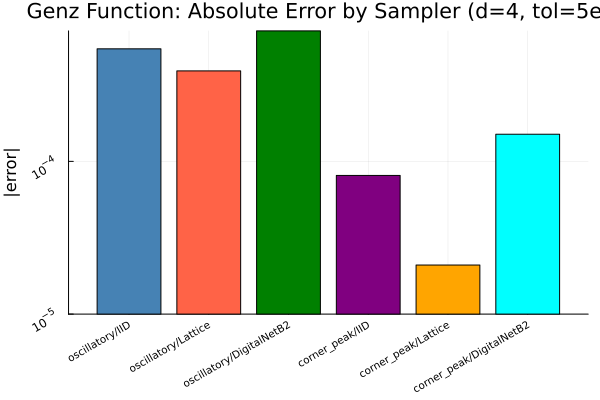

In [4]:
if HAVE_PLOTS
    err_vals = [abs(r.abs_error) for r in rows]
    labels   = ["$(r.kind)/$(r.sampler)" for r in rows]
    colors   = [:steelblue, :tomato, :green, :purple, :orange, :cyan]

    p = bar(labels, err_vals;
        color=colors[1:length(labels)],
        yscale=:log10, rotation=30,
        xlabel="Genz kind / Sampler", ylabel="|error|",
        title="Genz Function: Absolute Error by Sampler (d=$d, tol=5e-3)",
        legend=false, xtickfontsize=7)
    display(p)
end


The digital-net solver requires natural order in `QMC.jl`, so the notebook constructs `DigitalNetB2(...; graycode=false)` for the `CubQMCNetG` runs.
